In [23]:
def createRaw(arr, sfreq=2048,trigger_idx=0, eeg_start=1,eeg_end=65,l_freq=1,h_freq=55):
    orig_ch_names = (
        ["Trig1"]
        + [f"A{i}" for i in range(1, 33)]
        + [f"B{i}" for i in range(1, 33)]
    )
    eeg_dataa = arr[eeg_start:eeg_end, :]
    trigger = arr[trigger_idx, :]

# conversion of raw BioSemi ADC units (integer counts) to volts
    eeg_data_volts= eeg_dataa* 1e-6
    print("Max after scaling:", np.max(np.abs(eeg_data_volts)))

# ---------------------------------------------------
# 3. Create MNE Raw object
# ---------------------------------------------------

    ch_types = ["stim"]+ ["eeg"] * (eeg_end - eeg_start) 
    raw_data = np.vstack([trigger[None, :], eeg_data_volts])
    info = mne.create_info(ch_names=orig_ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(raw_data, info)
    montage = mne.channels.make_standard_montage("biosemi64")
    eeg_names = montage.ch_names  

    rename_dict = {"Trig1": "TRIGGER"}
    for old, new in zip(orig_ch_names[1:], eeg_names):
        rename_dict[old] = new

    raw.rename_channels(rename_dict)
    raw.set_channel_types({"TRIGGER": "stim"})
    raw.set_montage(montage)
    bads = mne.preprocessing.find_bad_channels_lof(raw, n_neighbors=20, picks='eeg', metric='euclidean', threshold=5)
    raw.info['bads'] = bads
    raw.interpolate_bads(reset_bads=True)
    #raw = raw.set_eeg_reference(ref_channels='average')
    raw.filter(l_freq=l_freq, h_freq=h_freq) 
    raw.resample(128.0, npad = "auto")
    return raw    
#raw_ica = raw.copy()
    #raw.save(
     #   r"E:\koorathota_data\pkl_data\pkl_data\pkl_data\newpkl\segmenteddata\subject_12_session_02_raw.fif",
      #  overwrite=True
    #)

In [2]:
def findSteering ( steering, timestamps, lookback_window = 0.75, threshold=0.3):
    absteering = abs(steering) #the absolute steering deviation 
    peaks =[]
    times = []
    mintime = 0 #the index of the samples I am to look in order to define a local maximum
    last_event_time = -np.inf
    for i in range(len(timestamps)-1): #the last timepoint is not important given that we are searching for motor events in a game 
        time = timestamps[i]
        if time - last_event_time < lookback_window: #non overlapping part
            continue
        while timestamps[mintime]<timestamps[i] -lookback_window:
            mintime+=1
        if absteering[i]<threshold:
            continue
        if absteering[i]==max(absteering[mintime:i+1]) and absteering[i] > absteering[i+1]:
            peaks.append(absteering[i])
            times.append(timestamps[i])
            last_event_time = time
            mintime = mintime+1
    
    
    return peaks, times
            

In [3]:
def epochsCreation (raw, peaks, times,eeg_start_time):
    fs=raw.info['sfreq']
    # Ο χρόνος έναρξης του EEG
# Μετατροπή χρόνου σε δείγματα (indices)
    event_samples = np.round( times-eeg_start_time)*fs
    event_samples += raw.first_samp
    limits = ((event_samples>=raw.first_samp) & (event_samples< raw.first_samp + raw.n_times))
    event_samples = event_samples[limits].astype(int)
# Δημιουργία πίνακα events για το MNE (3 στήλες: sample, 0, event_id)
    events = np.column_stack([
        event_samples,
        np.zeros(len(event_samples), dtype=int),
        np.ones(len(event_samples), dtype=int)
    ])
    event_id = dict(motor=1)
    epochs = mne.Epochs(
        raw, 
        events, 
        event_id=event_id,
        tmin=-1.2,           
        tmax=0.0,            
        baseline=(-1.2, -1.0), 
        preload=True,
        on_missing='warn',
        event_repeated='merge'
    )
    return epochs



In [26]:
def ICAProcess(epochs):
    reject_threshold = get_rejection_threshold(epochs, ch_types='eeg', decim=2)
    artifact_classes = [
    "eye blink",
    "muscle artifact",
    "heart",
    "line noise",
    "channel noise",
    ]
    artifacts = []
    ica = ICA(n_components=30,  method='infomax', random_state=42, max_iter='auto')
    #raw_eeg = raw_ica.copy().pick(picks='eeg')
    ica.fit(epochs, reject=reject_threshold)
    labels = mne_icalabel.label_components(raw_ica, ica, method= 'iclabel')
    #eog_inds, eog_scores = ica.find_bads_eog(raw_ica, ch_name="Fpz",threshold=3)
    #eog_inds1, eog_scores1 = ica.find_bads_eog(raw_ica, ch_name=["F7","F8"],threshold=3)
    #for i, (label, prob) in enumerate(zip(labels["labels"], labels["y_pred_proba"])):
     #   if label in artifact_classes and prob > 0.95:
      #      print(f"Excluding {label} (Prob: {prob:.2f})")
       #     artifacts.append(i)
    for i in range(len(labels["labels"])):
        label = labels["labels"][i]
        prob = labels["y_pred_proba"][i]
        if label== "eye blink"  and prob>0.9:
            print(label, prob)
            if i in artifacts:
                print("nothing")
            else:
                artifacts.append(i)
    ica.exclude =artifacts
    #ica.exclude = list(set(eog_inds) | set(artifacts))
    ica.apply(raw_ica)
    n_removed = len(ica.exclude)
    n_total = ica.n_components_
    return n_removed, n_total

In [27]:

reject_threshold = get_rejection_threshold(epochs, ch_types='eeg', decim=2)
artifact_classes = [
"eye blink",
"muscle artifact",
"heart",
"line noise",
"channel noise",
]
artifacts = []
ica = ICA(n_components=30,  method='infomax', random_state=42, max_iter='auto')
    #raw_eeg = raw_ica.copy().pick(picks='eeg')
ica.fit(epochs, reject=reject_threshold)
labels = mne_icalabel.label_components(epochs, ica, method= 'iclabel')
eog_inds, eog_scores = ica.find_bads_eog(epochs, ch_name="Fpz",threshold=3)
    #eog_inds1, eog_scores1 = ica.find_bads_eog(raw_ica, ch_name=["F7","F8"],threshold=3)
    #for i, (label, prob) in enumerate(zip(labels["labels"], labels["y_pred_proba"])):
     #   if label in artifact_classes and prob > 0.95:
      #      print(f"Excluding {label} (Prob: {prob:.2f})")
       #     artifacts.append(i)
for i in range(len(labels["labels"])):
    label = labels["labels"][i]
    prob = labels["y_pred_proba"][i]
    if label== "eye blink"  and prob>0.9:
        print(label, prob)
        if i in artifacts:
            print("nothing")
        else:
            artifacts.append(i)
    #ica.exclude =artifacts
    #ica.exclude = list(set(eog_inds) | set(artifacts))
    #ica.apply(raw_ica)
    #n_removed = len(ica.exclude)
    #n_total = ica.n_components_
    #return n_removed, n_total

C:\Users\USER\anaconda3\lib\site-packages\autoreject\autoreject.py:242: RuntimeWarning: The measurement information indicates a low-pass frequency of 55.0 Hz. The decim=2 parameter will result in a sampling frequency of 64.0 Hz, which can cause aliasing artifacts.
  epochs.decimate(decim=decim)


Estimating rejection dictionary for eeg
Fitting ICA to data using 64 channels (please be patient, this may take a while)


C:\Users\USER\AppData\Local\Temp\ipykernel_6788\2753258259.py:12: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs, reject=reject_threshold)
C:\Users\USER\AppData\Local\Temp\ipykernel_6788\2753258259.py:12: RuntimeWarning: The following parameters passed to ICA.fit() will be ignored, as they only affect raw data (and it appears you passed epochs): reject
  ica.fit(epochs, reject=reject_threshold)


Selecting by number: 30 components
Computing Infomax ICA
Fitting ICA took 9.1s.


C:\Users\USER\AppData\Local\Temp\ipykernel_6788\2753258259.py:13: RuntimeWarning: The provided Epochs instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(epochs, ica, method= 'iclabel')
C:\Users\USER\AppData\Local\Temp\ipykernel_6788\2753258259.py:13: RuntimeWarning: The provided Epochs instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(epochs, ica, method= 'iclabel')
C:\Users\USER\AppData\Local\Temp\ipykernel_6788\2753258259.py:13: RuntimeWarning: The provided ICA instance was fitted with a 'infomax' algorithm. ICLabel was designed with extended infomax ICA de

Using EOG channel: Fpz
eye blink 0.98274547
eye blink 0.9995912


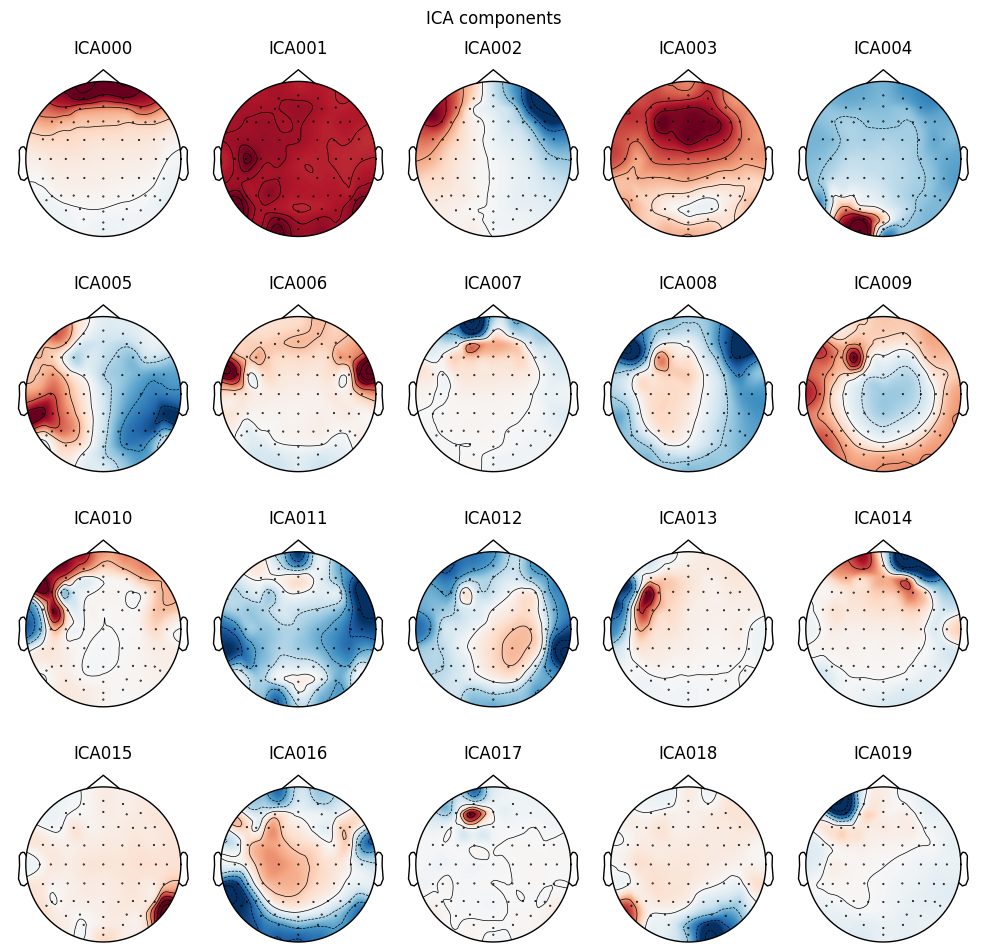

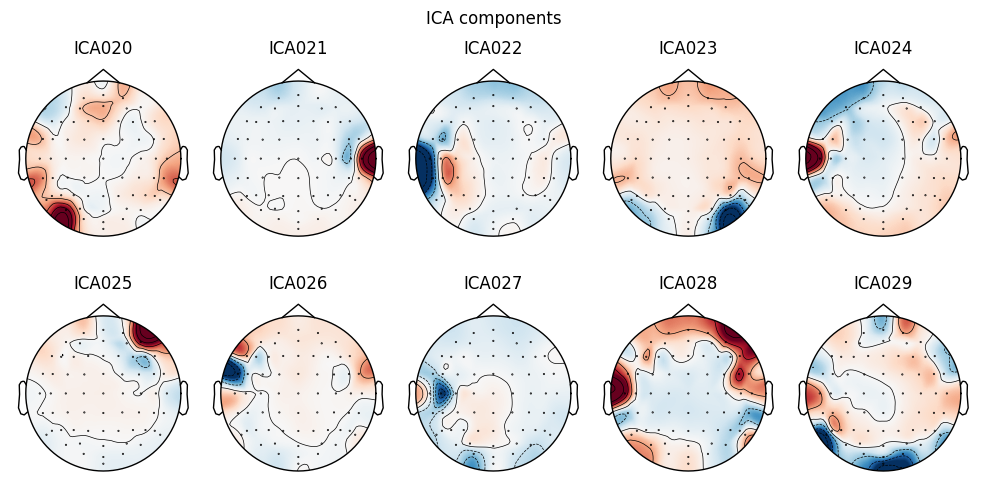

In [28]:
res= ica.plot_components()

In [29]:
print(labels)

{'y_pred_proba': array([0.98274547, 0.93972033, 0.9995912 , 0.4936458 , 0.5584882 ,
       0.96300346, 0.41957945, 0.9554277 , 0.39613897, 0.7631607 ,
       0.47200054, 0.9001244 , 0.7573546 , 0.9705927 , 0.7409132 ,
       0.5965762 , 0.5881512 , 0.65537745, 0.48993757, 0.96011406,
       0.8510945 , 0.8350194 , 0.44306767, 0.8418129 , 0.8965259 ,
       0.99661577, 0.8392758 , 0.6765781 , 0.6929048 , 0.774897  ],
      dtype=float32), 'labels': ['eye blink', 'line noise', 'eye blink', 'brain', 'other', 'brain', 'brain', 'muscle artifact', 'brain', 'brain', 'muscle artifact', 'other', 'brain', 'muscle artifact', 'eye blink', 'muscle artifact', 'other', 'channel noise', 'brain', 'muscle artifact', 'other', 'muscle artifact', 'muscle artifact', 'other', 'other', 'muscle artifact', 'muscle artifact', 'other', 'other', 'other']}


In [30]:

ica.exclude = list(set(eog_inds) | set(artifacts))

epochs_ica = epochs.copy()
ica.apply(epochs_ica)


Applying ICA to Epochs instance
    Transforming to ICA space (30 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components


C:\Users\USER\AppData\Local\Temp\ipykernel_6788\2146907234.py:4: RuntimeWarning: The data you passed to ICA.apply() was baseline-corrected. Please note that ICA can introduce DC shifts, therefore you may wish to consider baseline-correcting the cleaned data again.
  ica.apply(epochs_ica)


<Epochs | 154 events (all good), -1.203 – 0 s (baseline -1.2 – -1 s), ~11.9 MB, data loaded,
 'motor': 154>

In [4]:
import pickle
import numpy as np
import mne
from mne.preprocessing import ICA
import mne_icalabel
import matplotlib.pyplot as plt
import autoreject
with open("E:\\koorathota_data\\pkl_data\\pkl_data\\pkl_data\\newpkl\\Copy of 08_26_2022_11_53_52-Exp_adadrive-Sbj_12-Ssn_02.dats-028fixed.pkl", "rb") as f:
    data = pickle.load(f)
arr = data['BioSemi'][0]
raw = createRaw(arr)

C:\Users\USER\anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Max after scaling: 0.25944784374999996
Creating RawArray with float64 data, n_channels=65, n_times=3891602
    Range : 0 ... 3891601 =      0.000 ...  1900.196 secs
Ready.
LOF: Detected bad channel(s): ['P1']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 63 sensor positions
Interpolating 1 sensors
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 55 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 55.00 Hz
- Upper transitio

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.4s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.6s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:   28.6s finished


Trigger channel TRIGGER has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)


C:\Users\USER\AppData\Local\Temp\ipykernel_6788\2093194284.py:37: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  raw.resample(128.0, npad = "auto")


Trigger channel TRIGGER has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)


C:\Users\USER\AppData\Local\Temp\ipykernel_6788\2093194284.py:37: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  raw.resample(128.0, npad = "auto")


In [24]:
del raw
raw = createRaw(arr)

Max after scaling: 0.25944784374999996
Creating RawArray with float64 data, n_channels=65, n_times=3891602
    Range : 0 ... 3891601 =      0.000 ...  1900.196 secs
Ready.
LOF: Detected bad channel(s): ['P1']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 63 sensor positions
Interpolating 1 sensors
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 55 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 55.00 Hz
- Upper transition bandwidth: 13.75 Hz (-6 dB cutoff frequency: 61.88 Hz)
- Filter length: 6759 samples (3.300 s)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.5s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.9s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.3s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    1.6s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:   14.6s finished


Trigger channel TRIGGER has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)


C:\Users\USER\AppData\Local\Temp\ipykernel_6788\4196567871.py:37: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  raw.resample(128.0, npad = "auto")


Trigger channel TRIGGER has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)


C:\Users\USER\AppData\Local\Temp\ipykernel_6788\4196567871.py:37: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  raw.resample(128.0, npad = "auto")


In [25]:
from autoreject import AutoReject,get_rejection_threshold
motor = data['Unity_MotorInput']
steering = motor[0][0]
timestamps = motor[1]
biosemi_t = data['BioSemi'][1]
eeg_start_time = biosemi_t[0] 
peaks,times = findSteering(steering,timestamps)
epochs = epochsCreation (raw, peaks, times,eeg_start_time)


Not setting metadata
154 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 154 events and 155 original time points ...
0 bad epochs dropped


In [20]:
import pandas as pd

def get_variance_df(epochs, epochs_ica):
    """
    Compares variance between raw and clean EEG data and returns a Pandas DataFrame.
    """
    # 1. Pick only EEG channels to exclude triggers and other sensors
    # We work on copies to avoid altering your main variables
    dirty_eeg = epochs.copy().pick(picks='eeg')
    clean_eeg = epochs_ica.copy().pick(picks='eeg')
    
    # 2. Extract data and channel names
    data_dirty = dirty_eeg.get_data()
    data_clean = clean_eeg.get_data()
    ch_names = dirty_eeg.ch_names
    
    # 3. Calculate metrics using NumPy vectorized operations for speed
    # We calculate variance along the time axis (axis=1)
    vars_before = np.var(data_dirty, axis=(0,2))
    vars_after = np.var(data_clean, axis=(0,2))
    
    # Calculate % Reduction
    # Avoid division by zero if a channel is flat
    reduction = np.where(vars_before > 0, (1 - (vars_after / vars_before)) * 100, 0)
    
    # 4. Create the DataFrame
    df = pd.DataFrame({
        'Channel': ch_names,
        'Raw_Variance': vars_before,
        'Clean_Variance': vars_after,
        'Percent_Reduction': reduction
    })
    
    # 5. Sort by Percent_Reduction so blinks (highest reduction) are at the top
    df = df.sort_values(by='Percent_Reduction', ascending=False).reset_index(drop=True)
    
    return df

# --- Usage ---

# To see the top 10 rows:
# print(df_results.head(10))

# To save to Excel:
# df_results.to_excel("eeg_cleaning_validation.xlsx")

In [31]:
df_results =get_variance_df(epochs, epochs_ica)
print(df_results.to_string())

   Channel  Raw_Variance  Clean_Variance  Percent_Reduction
0      Fpz  1.145128e-09    1.213212e-10          89.405449
1      Fp2  1.234758e-09    1.825759e-10          85.213630
2      Fp1  1.477364e-09    2.950878e-10          80.026058
3      AF8  1.014186e-09    2.165675e-10          78.646177
4      AF7  8.479882e-10    2.307696e-10          72.786223
5      AF4  4.284539e-10    1.372531e-10          67.965484
6       F8  4.783816e-10    1.623256e-10          66.067770
7      AFz  4.520080e-10    1.550094e-10          65.706485
8       F7  5.046661e-10    1.810281e-10          64.129133
9       F6  3.350216e-10    1.426248e-10          57.428185
10     AF3  5.505606e-10    2.632440e-10          52.186196
11      F5  3.774846e-10    2.035876e-10          46.067309
12      F2  2.173157e-10    1.262371e-10          41.910761
13      F4  2.428867e-10    1.420443e-10          41.518317
14      F1  2.197142e-10    1.305050e-10          40.602397
15      Fz  2.202308e-10    1.336617e-10

In [16]:
# Check the "Inion" (Back of head) channel
# We want to see if we removed noise or beautiful alpha waves
ica.plot_overlay(epochs, exclude=ica.exclude, picks='Iz')

TypeError: inst must be an instance of Raw or Evoked, got <class 'mne.epochs.Epochs'> instead.

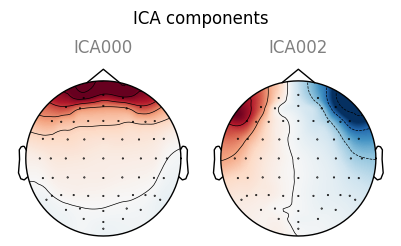

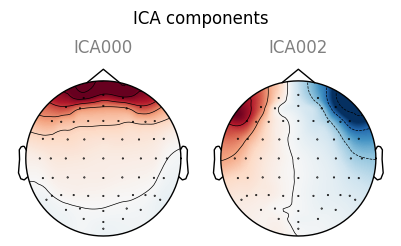

In [32]:
ica.plot_components(picks=ica.exclude)

In [33]:
def Autorejectf (epochs):
 
    n_interpolates = [1, 4, 8, 10]
    consensus_percs = [0.2, 0.35, 0.5, 0.8]
    ar = autoreject.AutoReject(n_interpolates, consensus_percs, picks='eeg',
                thresh_method='bayesian_optimization', random_state=42)
    
    ar.fit(epochs)
    epochs_ar, reject_log = ar.transform(epochs, return_log=True)
    if hasattr(ar, 'cv_scores_'):
        print("Επιτυχές Fit! Το RMSE είναι διαθέσιμο.")
    return epochs_ar, reject_log

In [34]:
def AutorejectValidation (epochs_ar, reject_log):
    evoked_before = epochs.average()

# Μέσος όρος μετά τον καθαρισμό με Autoreject
    evoked_after = epochs_ar.average()

# Σχεδίαση των Butterfly plots
    res=evoked_before.plot(titles='Before Autoreject')
    res=evoked_after.plot(titles='After Autoreject')
    res=reject_log.plot('horizontal')
    return evoked_after

Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/64 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/64 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/154 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/4 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/154 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.50 and n_interpolate=4


  0%|          | Repairing epochs : 0/154 [00:00<?,       ?it/s]

Dropped 11 epochs: 0, 4, 11, 34, 46, 48, 49, 55, 93, 122, 153


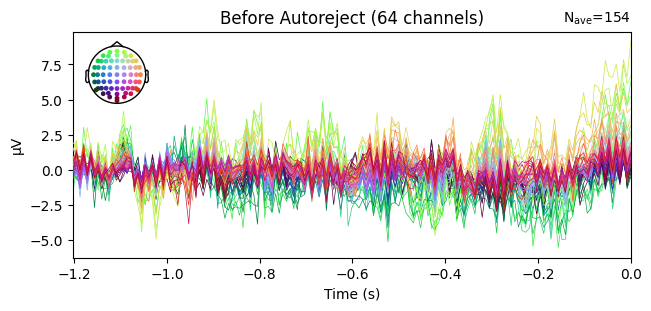

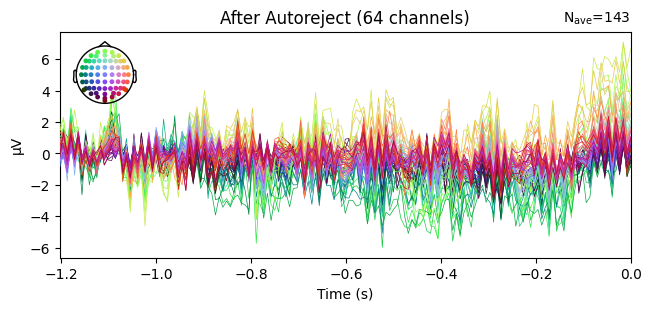

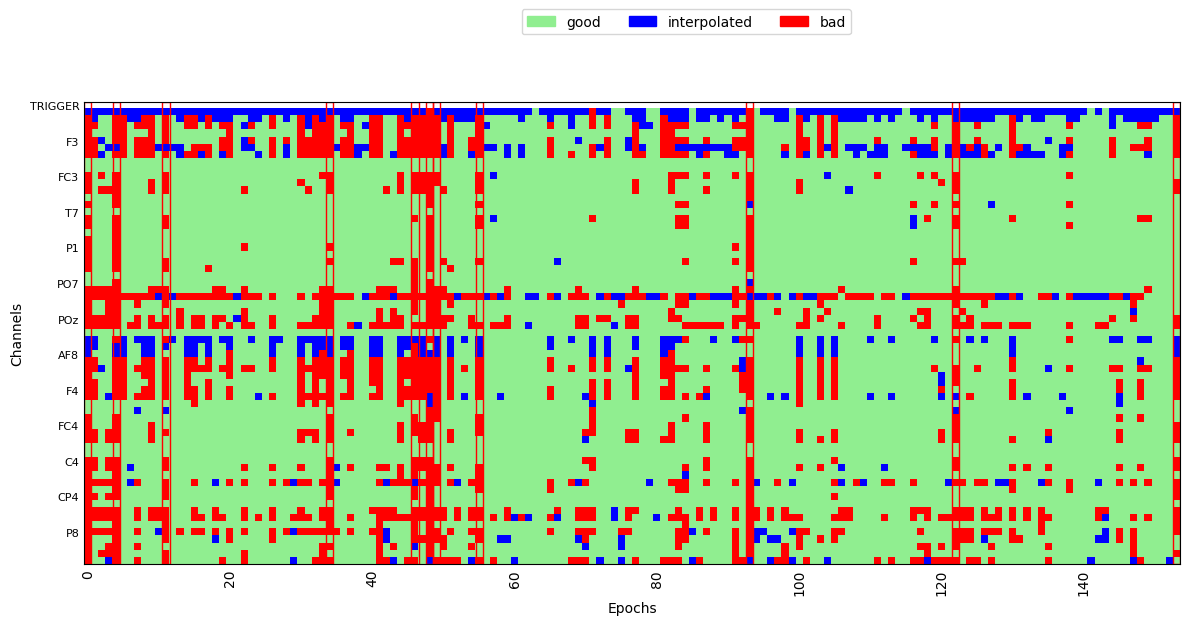

In [35]:
epochs_ar, reject_log = Autorejectf (epochs)
evoked_after = AutorejectValidation(epochs_ar, reject_log)


In [36]:
epochs_ar.set_eeg_reference(ref_channels='average', projection=False)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<Epochs | 143 events (all good), -1.203 – 0 s (baseline -1.2 – -1 s), ~11.1 MB, data loaded,
 'motor': 143>

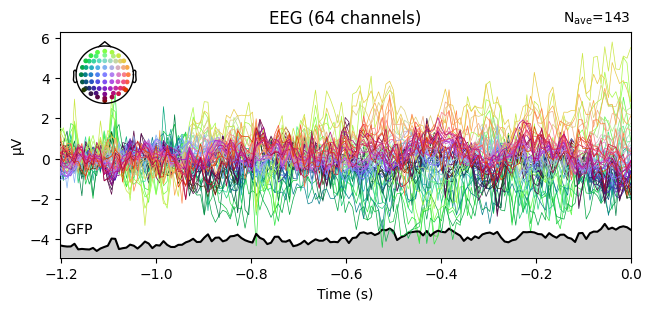

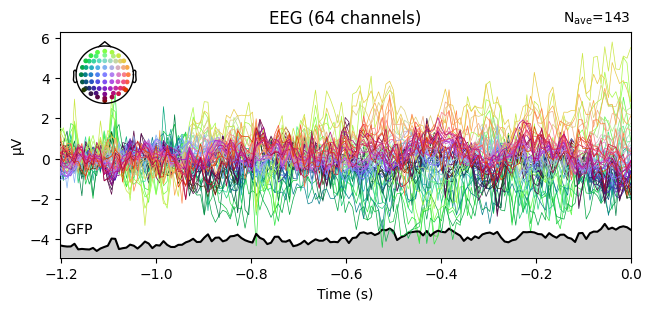

In [37]:
epochs_ar.average().plot(gfp=True, spatial_colors=True)

In [39]:
df_results1 =get_variance_df(epochs_ica, epochs_ar)
print(df_results1.to_string())

   Channel  Raw_Variance  Clean_Variance  Percent_Reduction
0      FC1  1.068454e-10    2.938198e-11          72.500467
1      FC2  1.046591e-10    2.931573e-11          71.989325
2      FC4  1.009179e-10    3.209137e-11          68.200517
3      FCz  1.249341e-10    4.001794e-11          67.968757
4       C4  8.705390e-11    3.134975e-11          63.988116
5       C2  8.129706e-11    3.008386e-11          62.995145
6       C1  8.627805e-11    3.207332e-11          62.825630
7       Fz  1.336617e-10    5.047975e-11          62.233197
8       Cz  7.875899e-11    3.178032e-11          59.648644
9       C3  8.878762e-11    3.604784e-11          59.399925
10     FC3  1.169529e-10    4.788731e-11          59.054183
11      F2  1.262371e-10    5.184073e-11          58.933830
12      F1  1.305050e-10    5.391608e-11          58.686576
13     CP4  7.521708e-11    3.868850e-11          48.564207
14      C6  1.166395e-10    6.130323e-11          47.442141
15     CP2  6.625425e-11    3.498539e-11